<a href="https://colab.research.google.com/github/tegarpng/Projek-Kelompok-29/blob/main/Percobaan1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Percobaan **1**

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od

# Masukkan link URL dataset Kaggle langsung di sini
od.download("https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: alfatih241
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data


100%|██████████| 151M/151M [00:01<00:00, 80.3MB/s]


In [3]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

mengimpor library yang digunakan. Pertama, cv2 adalah pustaka OpenCV yang digunakan untuk pemrosesan gambar dan video, sedangkan os digunakan untuk operasi sistem seperti manipulasi path file. library numpy diimpor sebagai np untuk perhitungan numerik yang efisien, sementara matplotlib.pyplot diimpor sebagai plt untuk visualisasi data dalam bentuk grafik. pandas digunakan untuk manipulasi data dan analisis dalam bentuk DataFrame, sedangkan math menyediakan fungsi matematika dasar. skimage.feature.graycomatrix dan skimage.feature.graycoprops yang bagian dari pustaka scikit-image yang digunakan untuk mengekstraksi fitur tekstur dari gambar, khususnya Gray-Level Co-occurrence Matrix (GLCM) dan propertinya. seaborn adalah pustaka visualisasi yang dibangun di atas Matplotlib, yang menyediakan antarmuka tingkat tinggi untuk membuat grafik yang lebih menarik. kemudian Scikit-Learn, beberapa metrik evaluasi seperti confusion_matrix, accuracy_score, precision_score, recall_score, dan f1_score diimpor untuk menilai performa model klasifikasi. SVC (Support Vector Classifier) diimpor untuk membuat model klasifikasi menggunakan metode Support Vector Machines. Selain itu, RandomForestClassifier dari Scikit-Learn juga diimpor untuk membuat model klasifikasi menggunakan algoritma Random Forest, yang menggabungkan beberapa pohon keputusan untuk meningkatkan akurasi prediksi.

In [4]:
data = []
labels = []
file_name = []

# Batasi 300 gambar per folder agar pengerjaan cepat & seimbang
class_counters = {'Brain Tumor': 0, 'Healthy': 0, 'glioma': 0, 'notumor': 0}
dataset_path = "brain-tumor-mri-data"

for root, dirs, files in os.walk(dataset_path):
    folder_aktif = os.path.basename(root)
    if folder_aktif in ['Brain Tumor', 'Healthy', 'glioma', 'notumor']:
        for filename in files:
            if class_counters[folder_aktif] >= 300:
                break
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                img = cv.imread(img_path)
                if img is not None:

                    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

                    data.append(img_gray)
                    labels.append(folder_aktif)
                    file_name.append(filename)
                    class_counters[folder_aktif] += 1

data = np.array(data, dtype=object)
labels = np.array(labels)
print(f"Sukses membaca data mentah! Total data awal: {len(data)} gambar.")

Sukses membaca data mentah! Total data awal: 600 gambar.


Menginisialisasi tiga list kosong yaitu data untuk menyimpan data gambar yang diproses, labels untuk menyimpan label kelas dari setiap gambar, dan file_name untuk menyimpan nama file asli dari setiap gambar. Variabel dataset_path didefinisikan sebagai "dataset/", menunjukkan lokasi root dari dataset gambar. Kemudian, kode ini melakukan iterasi melalui setiap sub-folder yang ada di dalam dataset_path. Untuk setiap item dalam direktori, kode memeriksa apakah itu benar-benar sebuah folder; jika bukan, maka item tersebut dilewati. Jika itu adalah sub-folder, kode akan masuk ke loop kedua untuk membaca setiap file gambar di dalamnya. Setiap file gambar dibaca menggunakan cv.imread, dikonversi menjadi grayscale dengan cv.cvtColor(img, cv.COLOR_BGR2GRAY). Gambar yang telah diproses ini kemudian ditambahkan ke list data, nama sub-folder ditambahkan ke list labels sebagai label kelas, dan nama file asli ditambahkan ke list file_name. Setelah semua gambar dari semua sub-folder selesai diproses, semua list (data, labels, dan file_name) dikonversi menjadi array NumPy.

In [5]:
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Kelas {u}: {c} gambar")
print(f"Total data: {len(data)} gambar")

Kelas glioma: 300 gambar
Kelas notumor: 300 gambar
Total data: 600 gambar


Block kode ini berfungsi untuk memverifikasi dan menampilkan distribusi jumlah data pada setiap kelas tumor otak secara dinamis dari array labels menggunakan fungsi np.unique(..., return_counts=True). Melalui perulangan zip(unique, counts), sistem akan memasangkan setiap nama kelas yang unik dengan total sampelnya untuk memastikan bahwa dataset yang digunakan kelompok kalian sudah seimbang (balanced) pas 300 gambar per kelas, sebelum akhirnya menampilkan total keseluruhan data (len(data)) yang siap masuk ke tahap ekstraksi fitur tekstur GLCM.

Block kode dibawah ini berfungsi untuk menampilkan visualisasi grafis berupa diagram batang (bar chart) dari distribusi jumlah data per kelas menggunakan pustaka `matplotlib.pyplot`. Berdasarkan data unik kelas dan jumlahnya yang telah dihitung sebelumnya (`unique` dan `counts`), diagram ini akan menggambarkan perbandingan kuantitas antar kelas secara visual dengan pewarnaan kustom (`skyblue` dan `salmon`), sehingga memudahkan dalam memverifikasi keseimbangan proporsi dataset sebelum melangkah ke proses analisis tekstur lebih lanjut.

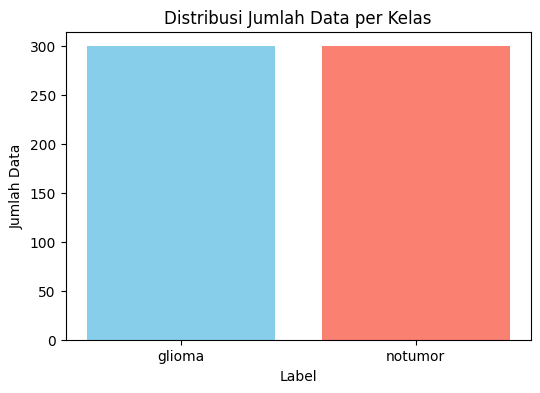

In [6]:
# Visualisasi distribusi data
plt.figure(figsize=(6,4))
plt.bar(unique, counts, color=['skyblue','salmon'])
plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.show()

Block kode dibawah ini berfungsi untuk menampilkan visualisasi sampel citra awal (data mentah) dari masing-masing kelas tumor otak sebanyak 5 gambar per baris dalam bentuk grid subplots. Proses ini dilakukan dengan menyisir setiap label unik pada dataset, mencari indeks gambar yang sesuai menggunakan list comprehension `[j for j, l in enumerate(labels) if l == label]`, lalu merendernya dalam skala keabu-abuan (`cmap='gray'`) tanpa menyertakan garis sumbu koordinat (`axis('off')`), sehingga kelompok kalian dapat melakukan inspeksi visual pertama terhadap variasi karakteristik bentuk fisik citra MRI sebelum dikenakan proses perbaikan kontras dan ekstraksi GLCM.

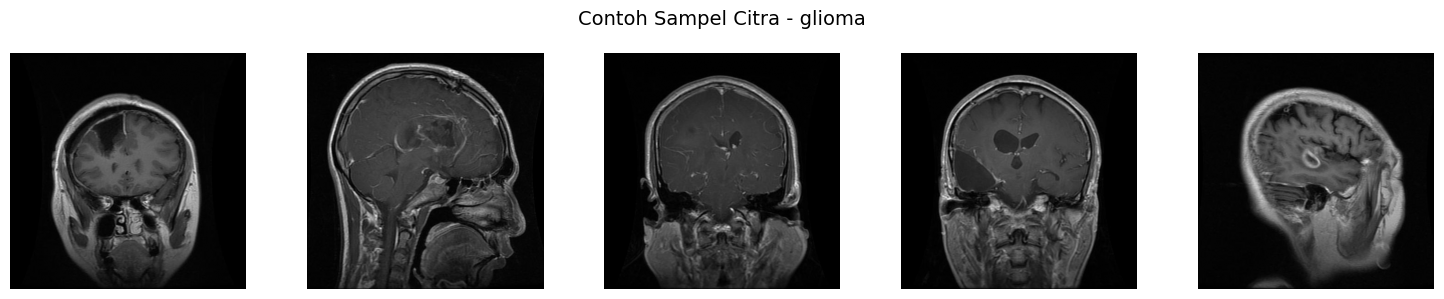

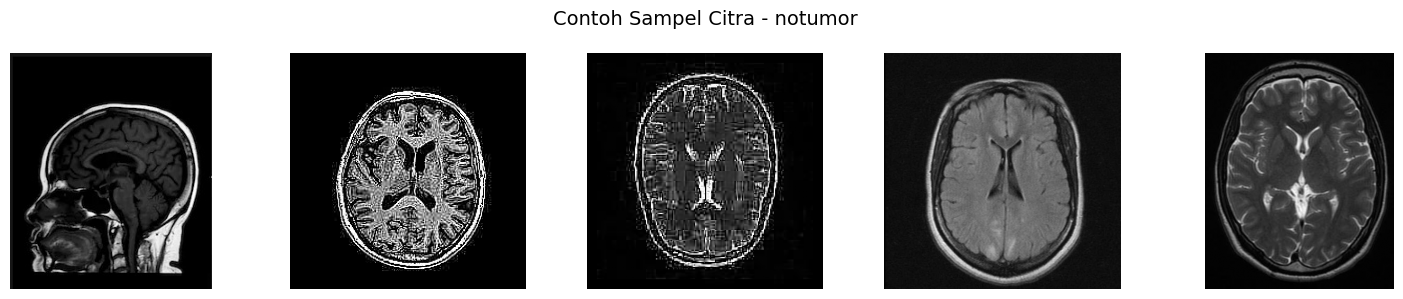

In [7]:
# Contoh sampel data tiap kelas
unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f'Contoh Sampel Citra - {label}', fontsize=14)
    for k in range(5):
        axs[k].imshow(data[idxs[k]], cmap='gray')
        axs[k].axis('off')
    plt.tight_layout()
    plt.show()

Block kode ini mendefinisikan rangkaian fungsi preprocessing utama untuk Percobaan 1, yang terdiri dari konversi skala keabu-abuan (`grayscale`), pengubahan ukuran dimensi citra menjadi standar (`resize`), serta peningkatan kualitas kontras lokal secara adaptif melalui fungsi `clahe`. Metode CLAHE yang dirancang secara manual ini membagi citra menjadi sub-blok berukuran $32 \times 32$ piksel, membatasi nilai histogram yang terlalu dominan menggunakan parameter `clip_limit` untuk mencegah pencahayaan berlebih (*over-saturation*), mendistribusikan ulang kelebihan piksel secara merata, kemudian memetakan kembali nilai intensitas berdasarkan akumulasi nilai CDF (*Cumulative Distribution Function*) lokal demi memunculkan detail struktur tekstur internal objek pada citra MRI otak tanpa merusak area latar belakang hitam.

In [15]:
def grayscale(image):
    if len(image.shape) == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return image

def resize(image, target_size):
    return cv.resize(image, target_size)


def clahe(citra, block_size=32, clip_limit=2.5):
    height, width = citra.shape
    hasil = np.zeros_like(citra)

    for i in range(0, height, block_size):
        for j in range(0, width, block_size):
            blok = citra[i:i+block_size, j:j+block_size]
            h_blok, w_blok = blok.shape

            hist = np.zeros(256, dtype=int)
            for bi in range(h_blok):
                for bj in range(w_blok):
                    hist[blok[bi][bj]] += 1

            total_piksel = h_blok * w_blok
            limit = int(clip_limit * total_piksel / 256)

            kelebihan = 0
            for c in range(256):
                if hist[c] > limit:
                    kelebihan += hist[c] - limit
                    hist[c] = limit

            distribusi_rata = kelebihan // 256
            sisa = kelebihan % 256

            for c in range(256):
                hist[c] += distribusi_rata
            for c in range(sisa):
                hist[c] += 1

            cdf = np.zeros(256, dtype=int)
            cdf[0] = hist[0]
            for c in range(1, 256):
                cdf[c] = cdf[c-1] + hist[c]

            cdf_min = cdf[cdf > 0][0] if len(cdf[cdf > 0]) > 0 else 0
            cdf_normal = np.zeros(256, dtype=int)
            for c in range(256):
                if total_piksel - cdf_min > 0:
                    cdf_normal[c] = np.round((cdf[c] - cdf_min) * 255 / (total_piksel - cdf_min))

            for bi in range(h_blok):
                for bj in range(w_blok):
                    hasil[i+bi][j+bj] = cdf_normal[blok[bi][bj]]

    return hasil

Block kode ini merupakan alur utama eksekusi preprocessing untuk Percobaan 1 yang menggabungkan seluruh tahapan (`grayscale`, `resize`, dan `clahe`) ke dalam fungsi `percobaan1`. Sistem melakukan perulangan untuk memproses seluruh citra mentah di dalam array `data` tanpa augmentasi, menyimpannya ke dalam list `dataPreprocessed`, lalu mengubahnya menjadi array NumPy. Setelah proses reduksi selesai, kode ini menampilkan visualisasi hasil preprocessing dalam bentuk grid matriks subplots berukuran $4 \times 6$ untuk setiap kelas label unik guna memverifikasi secara visual bahwa 24 sampel citra pertama dari masing-masing jenis tumor otak telah berhasil ditingkatkan kualitas kontras lokalnya secara seragam.

Sedang mengeksekusi Preprocessing Percobaan 1 ...
--- Selesai! ---
Total citra hasil Percobaan 1: 600 gambar.


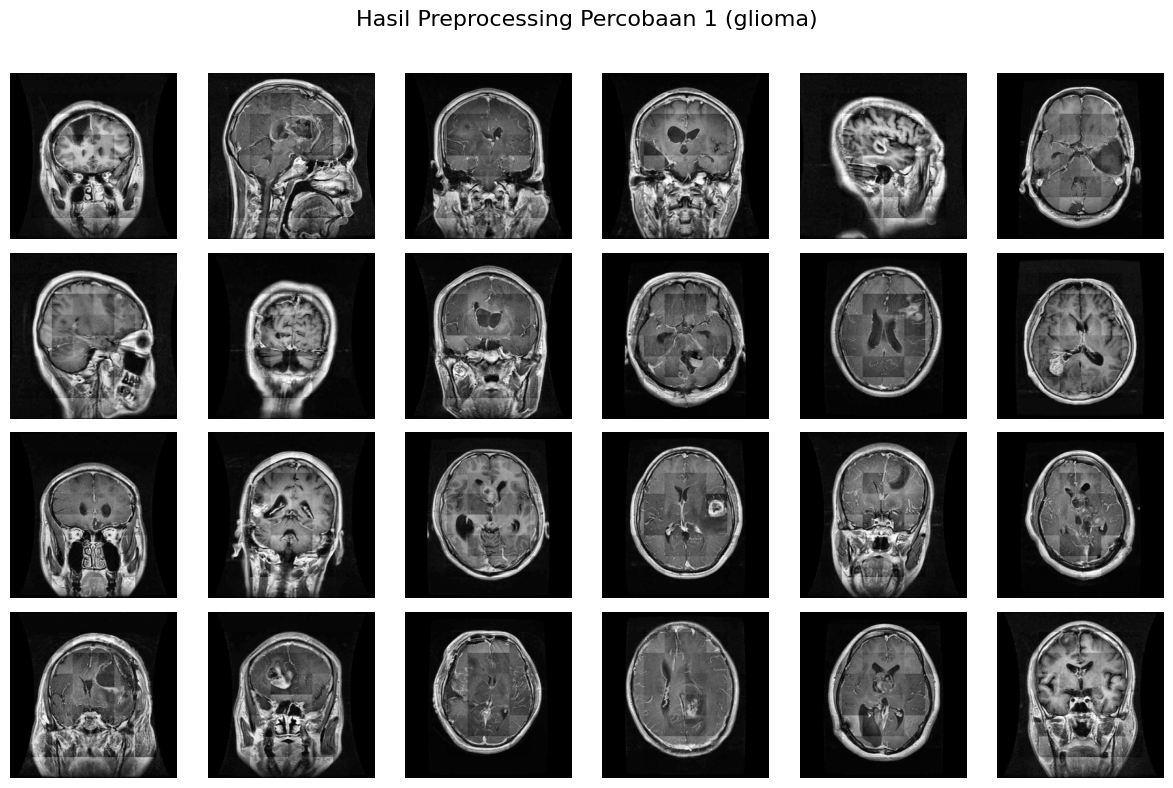

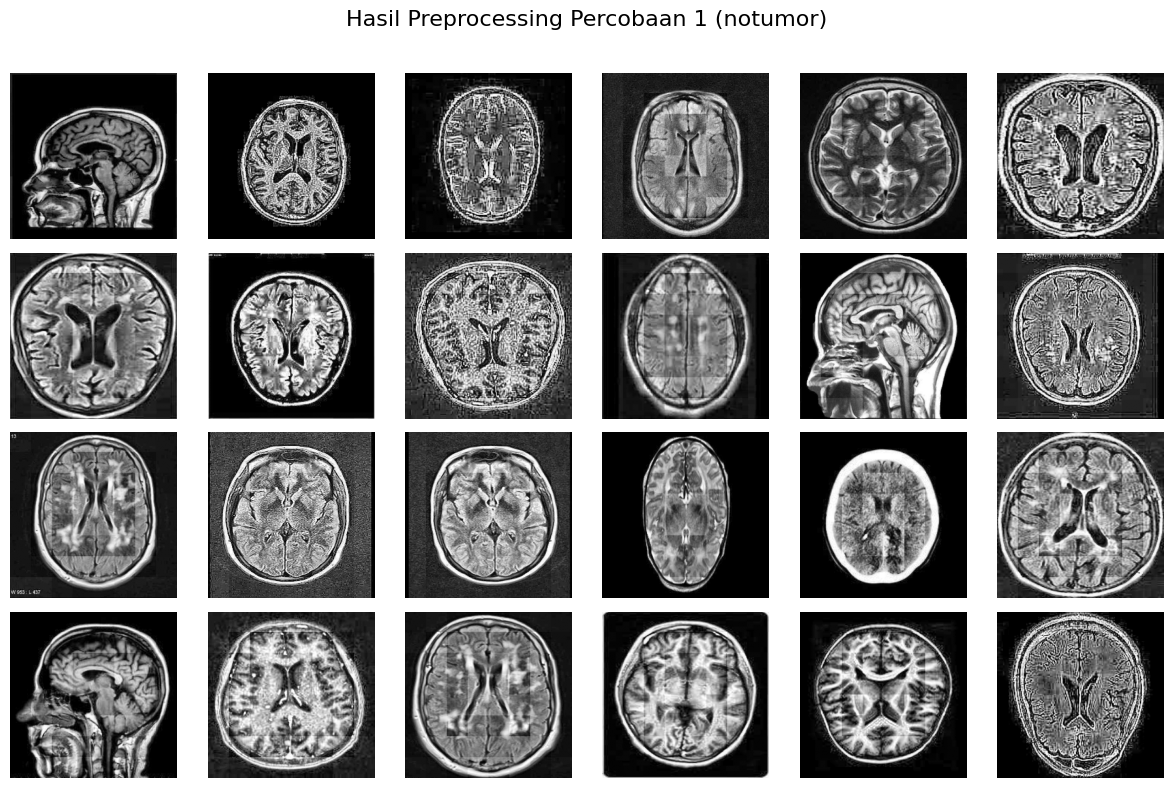

In [16]:
def percobaan1(image):
    img_gray = grayscale(image)
    img_resize = resize(img_gray, (256, 256))
    img_equalized = clahe(img_resize, block_size=32, clip_limit=2.5)
    return img_equalized

dataPreprocessed = []

print("Sedang mengeksekusi Preprocessing Percobaan 1 ...")

for i in range(len(data)):
    img_hasil = percobaan1(data[i])
    dataPreprocessed.append(img_hasil)

dataPreprocessed = np.array(dataPreprocessed)

print("--- Selesai! ---")
print(f"Total citra hasil Percobaan 1: {len(dataPreprocessed)} gambar.")

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Hasil Preprocessing Percobaan 1 ({label})', fontsize=16)

    for k in range(24):
        row = k // 6
        col = k % 6
        ax = axs[row][col]

        img_idx = idxs[k]
        ax.imshow(dataPreprocessed[img_idx], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [17]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

    return glcm

In [18]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [19]:
# Fungsi ekstraksi fitur untuk list citra
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0

        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan1')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,287.255147,0.968825,0.227534,0.497144,8.095619,0.051772,6.476372,percobaan1
1,553.203569,0.922106,0.045897,0.240585,13.475383,0.002107,8.460578,percobaan1
2,337.040349,0.951909,0.233099,0.450019,9.153952,0.054335,6.681659,percobaan1
3,428.219884,0.951937,0.233666,0.446872,10.315227,0.054600,6.830203,percobaan1
4,223.686397,0.977141,0.107001,0.384048,7.954504,0.011449,7.249726,percobaan1
...,...,...,...,...,...,...,...,...
595,312.929013,0.956400,0.093417,0.252519,10.667096,0.008727,8.202902,percobaan1
596,618.344256,0.957929,0.375891,0.429280,13.171247,0.141294,6.679554,percobaan1
597,461.153983,0.962061,0.558128,0.590538,9.867157,0.311507,4.877082,percobaan1
598,1970.438817,0.827574,0.165392,0.416258,23.360937,0.027355,7.498152,percobaan1


In [20]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(data)):
    D0 = glcm(data[i], 0)
    D45 = glcm(data[i], 45)
    D90 = glcm(data[i], 90)
    D135 = glcm(data[i], 135)

    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("--- Sukses membuat matriks derajat sudut GLCM! ---")

--- Sukses membuat matriks derajat sudut GLCM! ---


In [21]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(dataPreprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

In [22]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

In [35]:
dataTable = {
    'Filename': file_name,
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
display(hasilEkstrak)

from google.colab import files
files.download('hasil_ekstraksi_percobaan1.csv')

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,gl-0705.jpg,glioma,287.255147,445.666759,236.456143,475.455855,0.497144,0.442921,0.504095,0.442823,...,0.053202,0.048811,0.227534,0.220934,0.230655,0.220933,0.968825,0.951705,0.974343,0.948477
1,gl-1531.jpg,glioma,553.203569,934.568781,501.488297,886.583822,0.240585,0.181129,0.231732,0.182100,...,0.002015,0.001500,0.045897,0.038514,0.044884,0.038729,0.922106,0.868272,0.929411,0.875036
2,gl-1179.jpg,glioma,337.040349,523.486690,281.048407,549.555433,0.450019,0.412583,0.463718,0.412858,...,0.055947,0.052055,0.233099,0.228129,0.236532,0.228156,0.951909,0.925383,0.959922,0.921667
3,gl-0054.jpg,glioma,428.219884,708.014564,389.645205,720.329581,0.446872,0.412558,0.458123,0.411039,...,0.056239,0.052112,0.233666,0.228348,0.237149,0.228281,0.951937,0.920594,0.956284,0.919212
4,gl-0861.jpg,glioma,223.686397,403.161307,253.387929,452.323722,0.384048,0.294948,0.368058,0.291250,...,0.010927,0.007969,0.107001,0.089566,0.104531,0.089267,0.977141,0.958840,0.974105,0.953821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,no-1910.jpg,notumor,312.929013,549.273864,296.605254,554.728766,0.252519,0.198213,0.251080,0.197443,...,0.009991,0.008367,0.093417,0.091796,0.099953,0.091472,0.956400,0.923583,0.958944,0.922824
596,no-0367.jpg,notumor,618.344256,1308.792480,976.941452,1314.334318,0.429280,0.403026,0.416544,0.401901,...,0.138828,0.135416,0.375891,0.368160,0.372597,0.367989,0.957929,0.911001,0.933531,0.910624
597,no-1724.jpg,notumor,461.153983,812.355402,473.602083,809.570411,0.590538,0.578281,0.596874,0.579263,...,0.313292,0.306960,0.558128,0.553870,0.559725,0.554040,0.962061,0.933318,0.961037,0.933547
598,no-0848.jpg,notumor,1970.438817,2729.337347,1289.293030,2794.749112,0.416258,0.388874,0.433293,0.387529,...,0.028390,0.025221,0.165392,0.158749,0.168494,0.158810,0.827574,0.761483,0.887187,0.755766


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: >

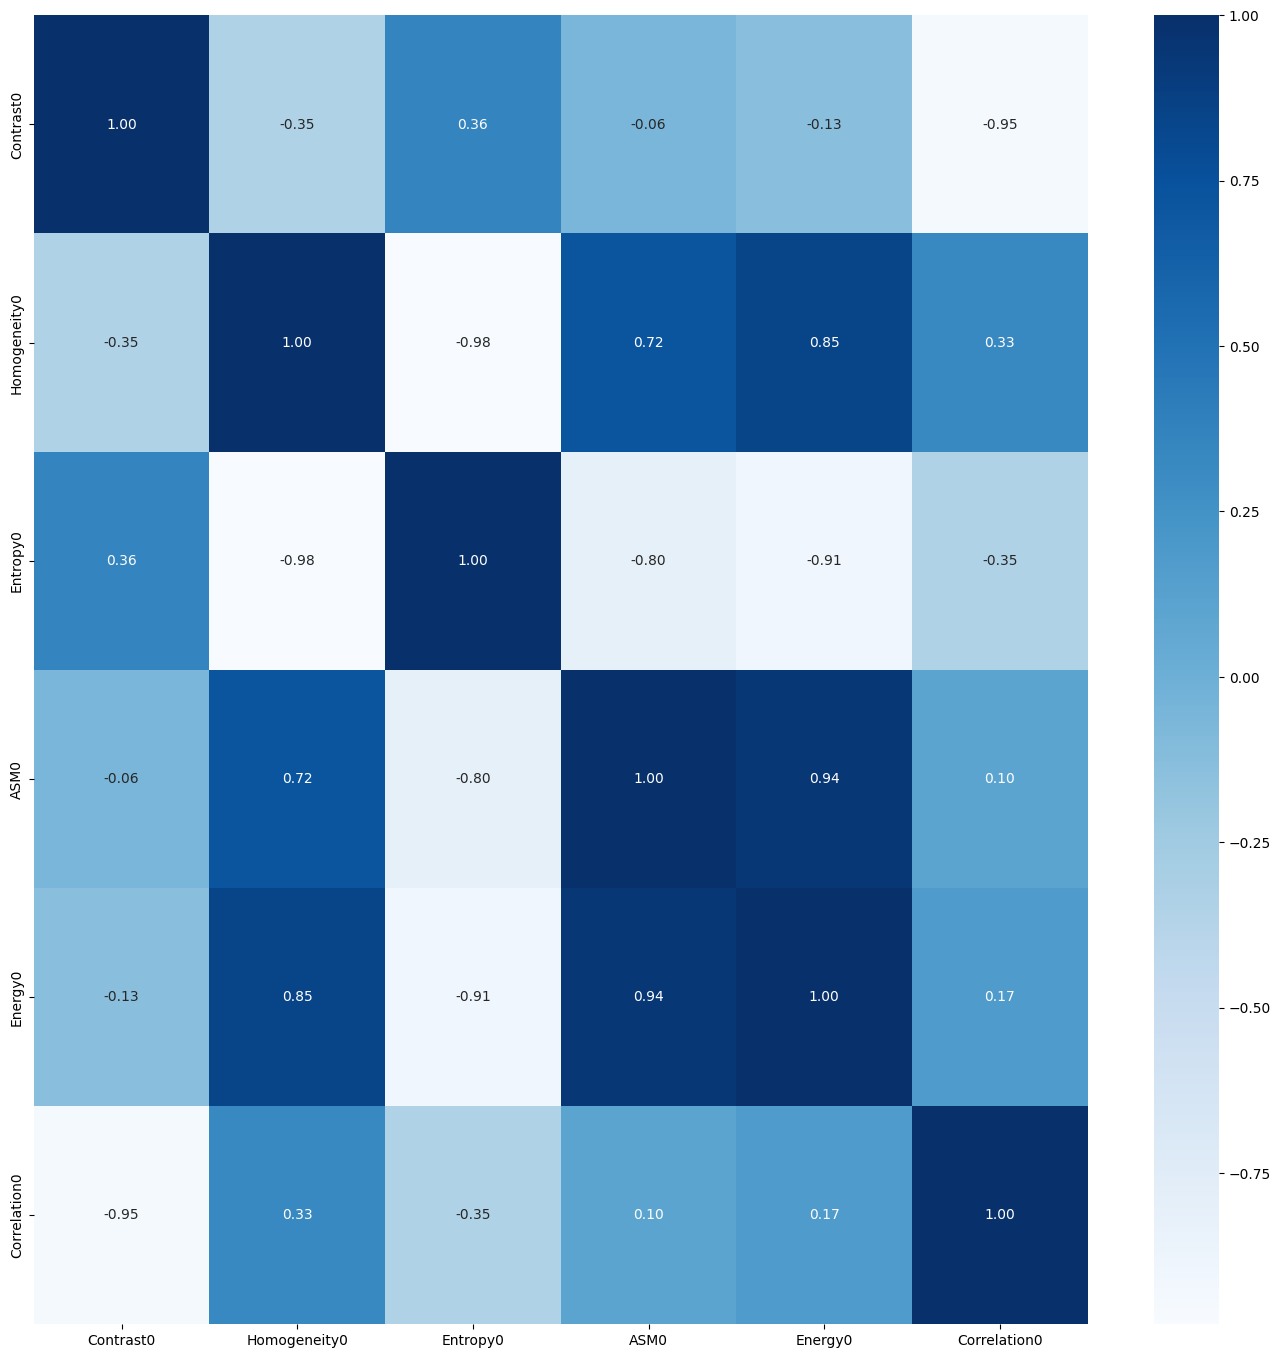

In [25]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


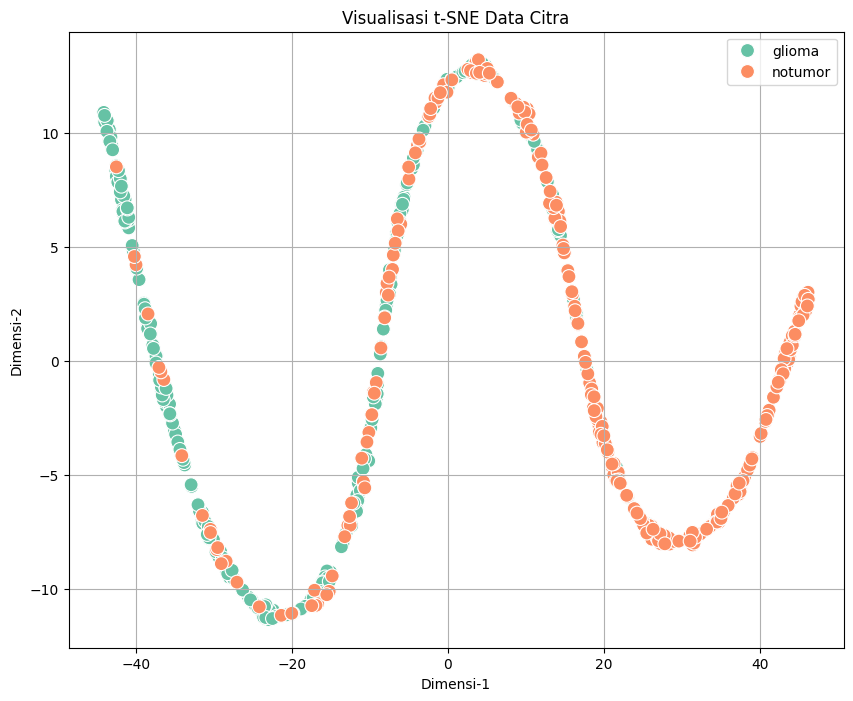

In [36]:
from sklearn.manifold import TSNE

# Jalankan t-SNE untuk reduksi ke 2 dimensi
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(x_new)

# Buat DataFrame hasil t-SNE
df_tsne = pd.DataFrame()
df_tsne['Dimensi-1'] = X_tsne[:, 0]
df_tsne['Dimensi-2'] = X_tsne[:, 1]
df_tsne['Label'] = y

# Plot dengan seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Dimensi-1', y='Dimensi-2', hue='Label', data=df_tsne, palette='Set2', s=100
)
plt.title('Visualisasi t-SNE Data Citra')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [26]:

X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(480, 6)
(120, 6)
(480,)
(120,)


In [27]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [29]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [30]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       238
     notumor       0.99      0.99      0.99       242

    accuracy                           0.99       480
   macro avg       0.99      0.99      0.99       480
weighted avg       0.99      0.99      0.99       480

[[235   3]
 [  2 240]]
Accuracy: 0.9895833333333334

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.87      0.89      0.88        62
     notumor       0.88      0.86      0.87        58

    accuracy                           0.88       120
   macro avg       0.88      0.87      0.87       120
weighted avg       0.88      0.88      0.87       120

[[55  7]
 [ 8 50]]
Accuracy: 0.875


In [31]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.86      0.89      0.88       238
     notumor       0.89      0.86      0.88       242

    accuracy                           0.88       480
   macro avg       0.88      0.88      0.88       480
weighted avg       0.88      0.88      0.88       480

[[213  25]
 [ 34 208]]
Accuracy: 0.8770833333333333

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.89      0.90      0.90        62
     notumor       0.89      0.88      0.89        58

    accuracy                           0.89       120
   macro avg       0.89      0.89      0.89       120
weighted avg       0.89      0.89      0.89       120

[[56  6]
 [ 7 51]]
Accuracy: 0.8916666666666667


In [32]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.89      0.97      0.93       238
     notumor       0.96      0.89      0.92       242

    accuracy                           0.93       480
   macro avg       0.93      0.93      0.93       480
weighted avg       0.93      0.93      0.93       480

[[230   8]
 [ 27 215]]
Accuracy: 0.9270833333333334

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.86      0.98      0.92        62
     notumor       0.98      0.83      0.90        58

    accuracy                           0.91       120
   macro avg       0.92      0.91      0.91       120
weighted avg       0.92      0.91      0.91       120

[[61  1]
 [10 48]]
Accuracy: 0.9083333333333333


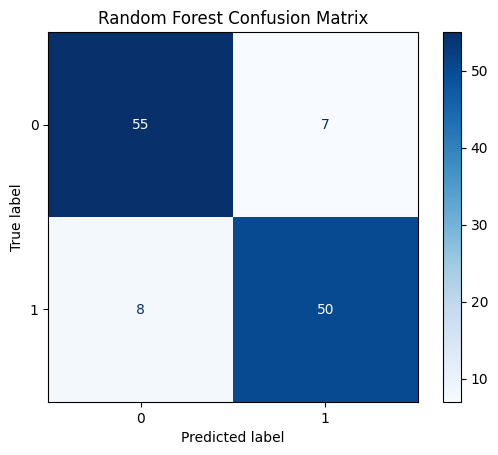

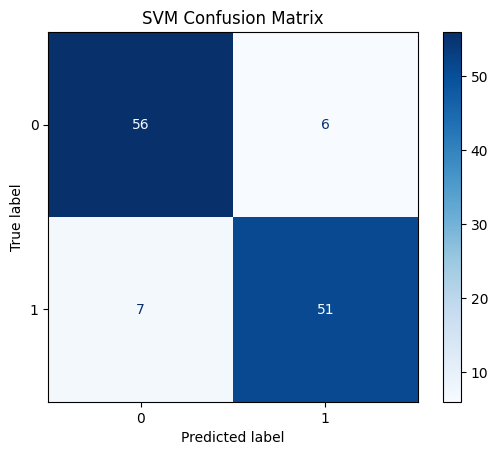

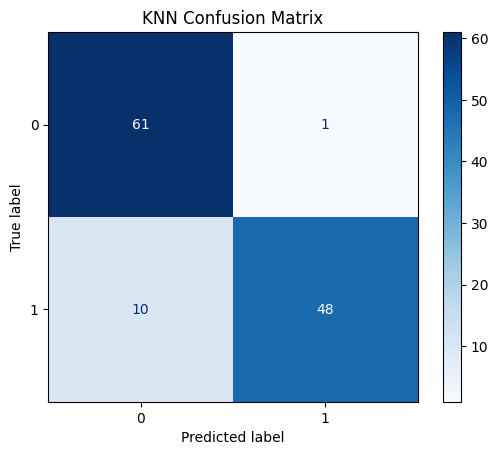

In [33]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")